<a href="https://colab.research.google.com/github/gabyxsantos/Acidentes-de-Minas-Gerais-em-2020/blob/main/jaima.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# 1. Carregar os dados (Ajuste os nomes dos arquivos conforme o que você subiu)
df_pir = pd.read_excel('Amostra_Piranguinho.xlsx')
df_lin = pd.read_excel('Amostra_Linguagem.xlsx')
df_sbz = pd.read_excel('Amostra_Sao_Braz.xlsx')

# **Introdução e Metodologia de Análise**
Este relatório apresenta a análise técnica das amostras de **Piranguinho**, **São Braz do Piauí** e a amostra temática de **Linguagem**, como parte integrante do **Projeto Jáima**. O objetivo central é mapear o perfil da formação docente e identificar as percepções e práticas de inclusão de alunos com deficiência (PCD) nas redes de ensino pesquisadas.

# **Normalização e Categorização de Cargos**
Devido à natureza qualitativa das respostas, foi aplicada uma padronização nas colunas de profissão.
Através de scripts em Python, agrupamos as diversas nomenclaturas em categorias funcionais:
Professores (regentes e especialistas) e Monitores/Apoio, permitindo uma análise comparativa precisa entre quem planeja e quem executa o suporte direto ao aluno.

In [ ]:
#criando uma função para a limpeza
def limpeza_profissao(texto):
    # Transformamos em minúsculo e guardamos na variável 'texto_limpo'
    texto_limpo = str(texto).lower()
    # Agora procuramos o termo dentro da variável que está TODA em minúsculo
    if 'monit' in texto_limpo or 'apoio' in texto_limpo:
        return 'Monitor'
    elif 'prof' in texto_limpo:
        return 'Professor'
    else:
        return 'Outros'


In [ ]:
#aplicando a limpeza
df_pir['Qual a sua profissão atual?'] = df_pir['Qual a sua profissão atual?'].apply(limpeza_profissao)
df_sbz['Qual a sua profissão atual?'] = df_sbz['Qual a sua profissão atual?'].apply(limpeza_profissao)

In [ ]:
print(df_pir['Qual a sua profissão atual?'].value_counts())

Qual a sua profissão atual?
Professor    48
Outros       20
Monitor      13
Name: count, dtype: int64


In [ ]:
print(df_sbz['Qual a sua profissão atual?'].value_counts())

Qual a sua profissão atual?
Professor    23
Outros       17
Name: count, dtype: int64


Tais resultados mostram que apenas os dados de Pirangui nos possibilitam diferenciar e entender as possíveis diferentes visões entre professores e monitores.

# **Análise - Piranguinho e São Braz**

Nesta etapa, mergulhamos nos dados das **cidades** de Piranguinho e São Braz do Piauí. Para não nos perdermos em meio a tantas perguntas, organizamos a análise em três grandes eixos (indicadores), conforme a metodologia do projeto.

O objetivo é transformar os textos das respostas em **Nuvens de Palavras**. Essa técnica nos permite identificar instantaneamente quais termos são mais frequentes e quais são as maiores preocupações dos profissionais de cada região.

Os eixos de análise são:

**Indicador Verde (Compreensão):** Focado em como os profissionais entendem o processo de inclusão e o que sentem que falta para compreender melhor esse universo.

**Indicador Azul (Políticas e Planejamento):** Voltado para o conhecimento de documentos obrigatórios (como PDI e PEI) e o suporte oferecido pela rede de ensino.

**Indicador Laranja (Práticas Pedagógicas):** Focado no "chão da escola", analisando as estratégias e atividades reais que os professores e monitores aplicam no dia a dia.

Para cada indicador, geramos visualizações separadas para **Professores e Monitores**, buscando entender se existe um alinhamento entre quem planeja e quem executa o apoio aos alunos.

In [ ]:
indicador_verde = [
    '1) Considerando que desde a Constituição de 1988, o direito de estudar na escola regular dos estudantes com deficiência têm sido afirmado e viabilizado, o que você considera que está faltando para compreender melhor esse processo (Inclusão Escolar)?',
    'Você sabe o que é Capacitismo?'
]
indicador_azul = [
    'Na rede que você atua tem uma política de formação para a Inclusão Escolar? ',
    'Você conhece o Planejamento Educacional Individualizado (PEI)?',
    'Você conhece o Plano de Desenvolvimento Individual (PDI)?'
]
indicador_laranja = [
    'No seu dia a dia, como são feitos os planejamentos de aulas para turmas que possuem alunos com deficiência participando delas?',
    'Cite uma atividade que você faz ou poderia fazer para que qualquer estudante (incluindo aqueles com deficiência) participe em sua aula.',
    'Cite uma atividade que você faz ou poderia fazer para que qualquer estudante (incluindo aqueles com deficiência) pudesse participar.',
    'Cite pelo menos duas estratégias que você poderia utilizar para promover a participação de um estudante com deficiência numa atividade em com toda a sua turma. '
]

## **Indicador Verde**

### **Pirangui**

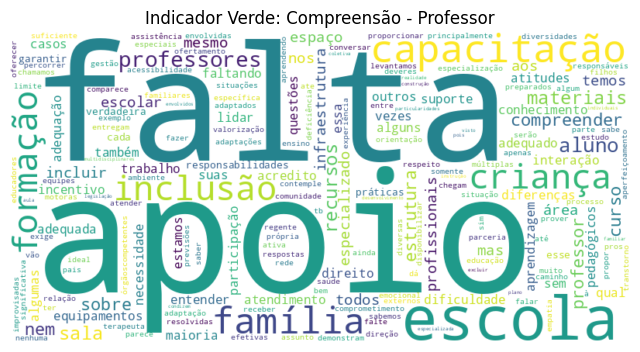

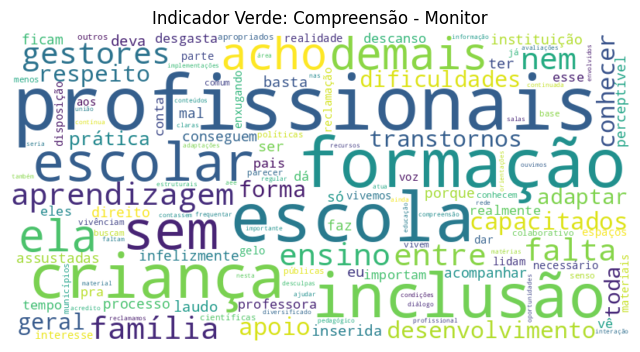

In [ ]:
pergunta_texto = indicador_verde[0]  # O que falta para a inclusão
pergunta_sim_nao = indicador_verde[1] # Você sabe o que é capacitismo?

# Lista de palavras para ignorar nas nuvens
stopwords_pt = ['que', 'de', 'o', 'a', 'com', 'do', 'da', 'em', 'um', 'para', 'é', 'dos', 'das', 'os', 'as', 'na', 'no', 'por', 'mais', 'se',
                'uma', 'ou', 'como', 'tem', 'ao', 'seu', 'sua', 'está', 'pelo', 'pela', 'são', 'este', 'esta',
                'e', 'não', 'numa']

def criar_nuvem(df, cargo, titulo):
    texto = " ".join(df[df['Qual a sua profissão atual?'] == cargo][pergunta_texto].dropna().astype(str))

    if len(texto.strip()) > 5: # Só gera se tiver texto suficiente
        nuvem = WordCloud(width=800, height=400, background_color='white', stopwords=stopwords_pt).generate(texto.lower())
        plt.figure(figsize=(8, 5))
        plt.imshow(nuvem, interpolation='bilinear')
        plt.axis('off')
        plt.title(f'{titulo} - {cargo}')
        plt.show()
    else:
        print(f"Sem dados suficientes para gerar nuvem de: {cargo}")

criar_nuvem(df_pir, 'Professor', 'Indicador Verde: Compreensão')
criar_nuvem(df_pir, 'Monitor', 'Indicador Verde: Compreensão')




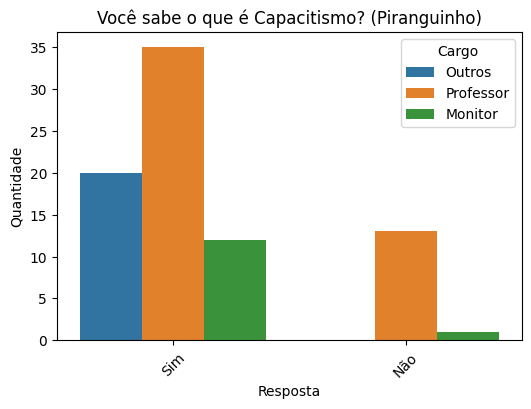

In [ ]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df_pir, x=pergunta_sim_nao, hue='Qual a sua profissão atual?')

plt.title('Você sabe o que é Capacitismo? (Piranguinho)')
plt.xlabel('Resposta')
plt.ylabel('Quantidade')
plt.legend(title='Cargo')
plt.xticks(rotation=45) # Rotaciona os nomes se forem grandes
plt.show()

**Conclusões Pirangui:**
por meio das nuvens de palavras, nota-se que em Piranguinho, o Indicador Verde revela um cenário onde a teoria e a prática estão em tempos diferentes.

Embora a maioria dos profissionais saiba identificar o capacitismo, o dia a dia é marcado por um forte sentimento de 'falta de apoio' e necessidade de 'formação'. Enquanto **professore**s clamam por **estrutura e suporte**, **monitore**s buscam **reconhecimento profissional** e capacitação técnica para efetivar a inclusão escolar.

### **São Braz do Piauí**

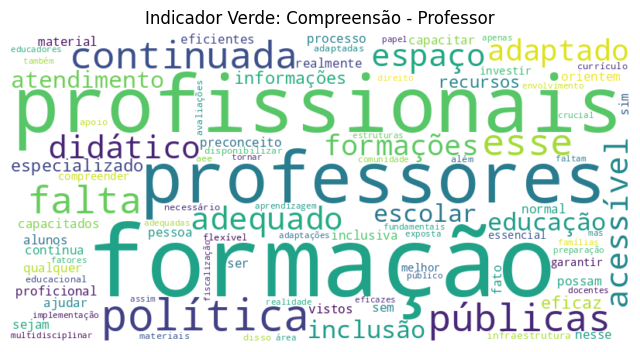

Sem dados suficientes para gerar nuvem de: Monitor


In [ ]:
pergunta_texto = indicador_verde[0]  # O que falta para a inclusão
pergunta_sim_nao = indicador_verde[1] # Você sabe o que é capacitismo?

stopwords_pt = ['que', 'de', 'o', 'a', 'com', 'do', 'da', 'em', 'um', 'para', 'é', 'dos', 'das', 'os', 'as', 'na', 'no', 'por', 'mais', 'se',
                'uma', 'ou', 'como', 'tem', 'ao', 'seu', 'sua', 'está', 'pelo', 'pela', 'são', 'este', 'esta',
                'e', 'não', 'numa']

def criar_nuvem(df, cargo, titulo):
    texto = " ".join(df[df['Qual a sua profissão atual?'] == cargo][pergunta_texto].dropna().astype(str))

    if len(texto.strip()) > 5:
        nuvem = WordCloud(width=800, height=400, background_color='white', stopwords=stopwords_pt).generate(texto.lower())
        plt.figure(figsize=(8, 5))
        plt.imshow(nuvem, interpolation='bilinear')
        plt.axis('off')
        plt.title(f'{titulo} - {cargo}')
        plt.show()
    else:
        print(f"Sem dados suficientes para gerar nuvem de: {cargo}")

criar_nuvem(df_sbz, 'Professor', 'Indicador Verde: Compreensão')
criar_nuvem(df_sbz, 'Monitor', 'Indicador Verde: Compreensão')


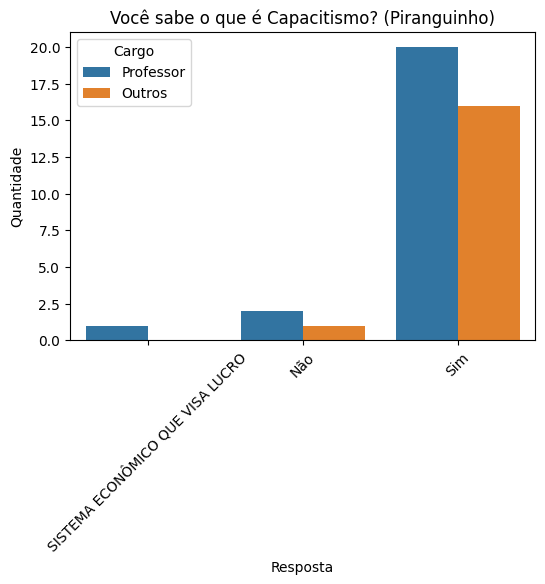

In [ ]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df_sbz, x=pergunta_sim_nao, hue='Qual a sua profissão atual?')

plt.title('Você sabe o que é Capacitismo? (Piranguinho)')
plt.xlabel('Resposta')
plt.ylabel('Quantidade')
plt.legend(title='Cargo')
plt.xticks(rotation=45) # Rotaciona os nomes se forem grandes
plt.show()

**Conclusões São Braz do Piauí:** em São Braz do Piauí, o Indicador Verde revela que a grande prioridade da rede é a estruturação teórica e institucional.

Diferente de outras amostras, o corpo docente foca massivamente na necessidade de **formação continuada** e na criação de **políticas públicas** claras, indicando que os profissionais buscam um respaldo oficial e técnico para atuar com a inclusão. Embora o conceito de **capacitism**o seja amplamente conhecido, as respostas reforçam que ainda falta traduzir esse conhecimento em diretrizes didáticas e práticas acessíveis para o dia a dia escolar.

## **Indicador Azul**

### **Pirangui**

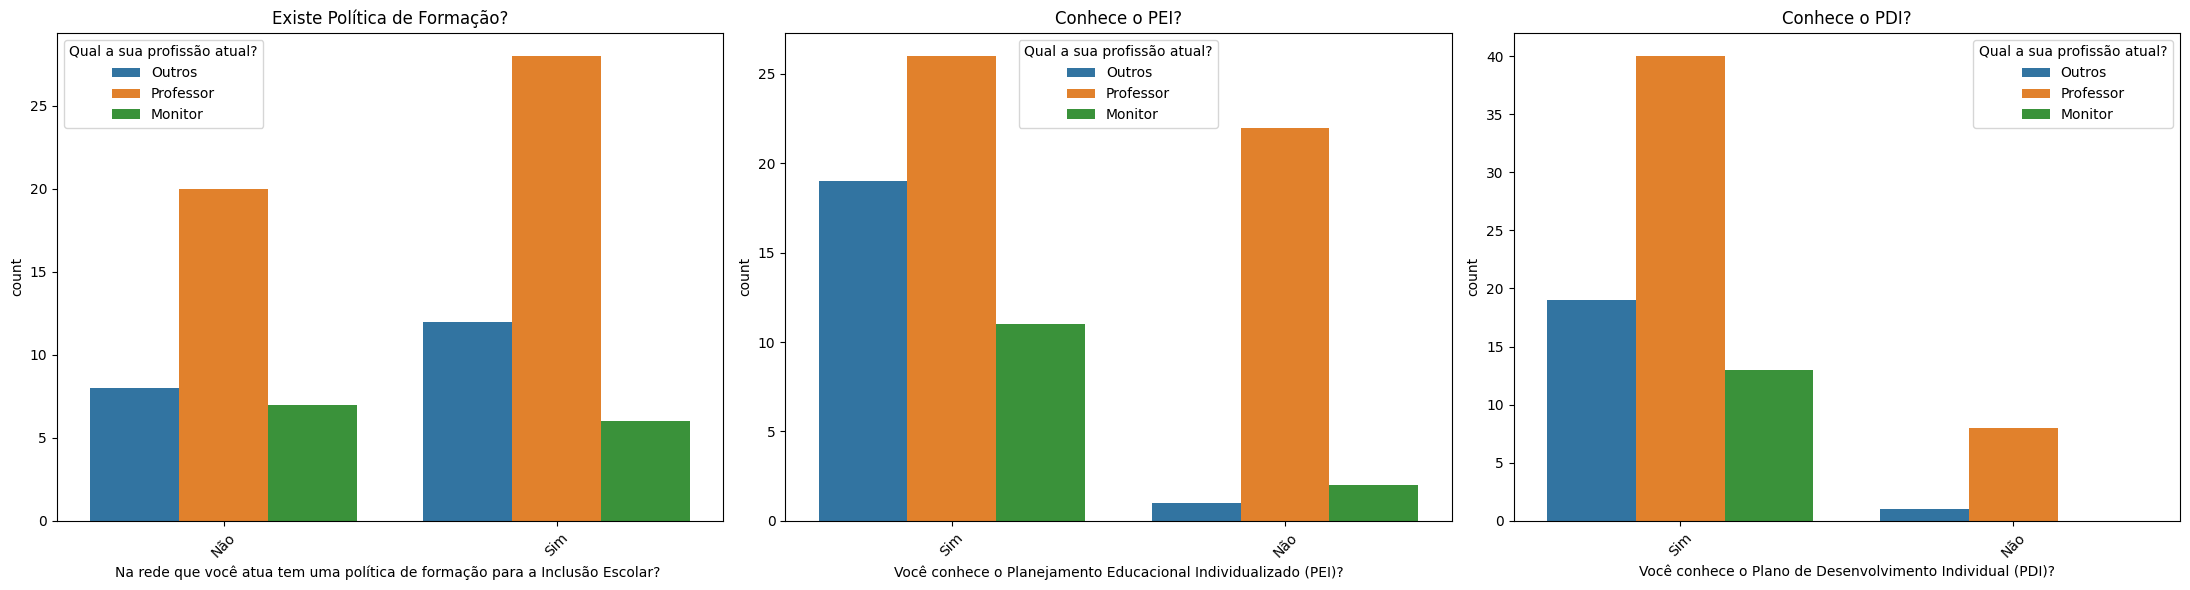

In [ ]:
col_politica = indicador_azul[0]
col_pei = indicador_azul[1]
col_pdi = indicador_azul[2]

fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# Gráfico 1: Política de Formação
sns.countplot(data=df_pir, x=col_politica, hue='Qual a sua profissão atual?', ax=axes[0])
axes[0].set_title('Existe Política de Formação?')
axes[0].tick_params(axis='x', rotation=45)

# Gráfico 2: Conhece o PEI?
sns.countplot(data=df_pir, x=col_pei, hue='Qual a sua profissão atual?', ax=axes[1])
axes[1].set_title('Conhece o PEI?')
axes[1].tick_params(axis='x', rotation=45)

# Gráfico 3: Conhece o PDI?
sns.countplot(data=df_pir, x=col_pdi, hue='Qual a sua profissão atual?', ax=axes[2])
axes[2].set_title('Conhece o PDI?')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

**Conclusões Pirangui:** O Indicador Azul em Piranguinho aponta que, diferente do PDI, que parece ser um documento de domínio público na rede, o PEI (Planejamento Educacional Individualizado) divide a opinião dos docentes. Praticamente metade dos professores de Piranguinho afirma não conhecer o PEI. Isso sugere que, embora exista um plano de desenvolvimento para o aluno (PDI), a parte do planejamento pedagógico prático e individualizado (PEI) ainda não está totalmente integrada à rotina dos professores regentes.

Além disso, é notório que uma parte considerável respondeu que na rede que atua não existem políticas de formação, um 'gap' importante a ser avaliado.

### **São Braz do Piauí**

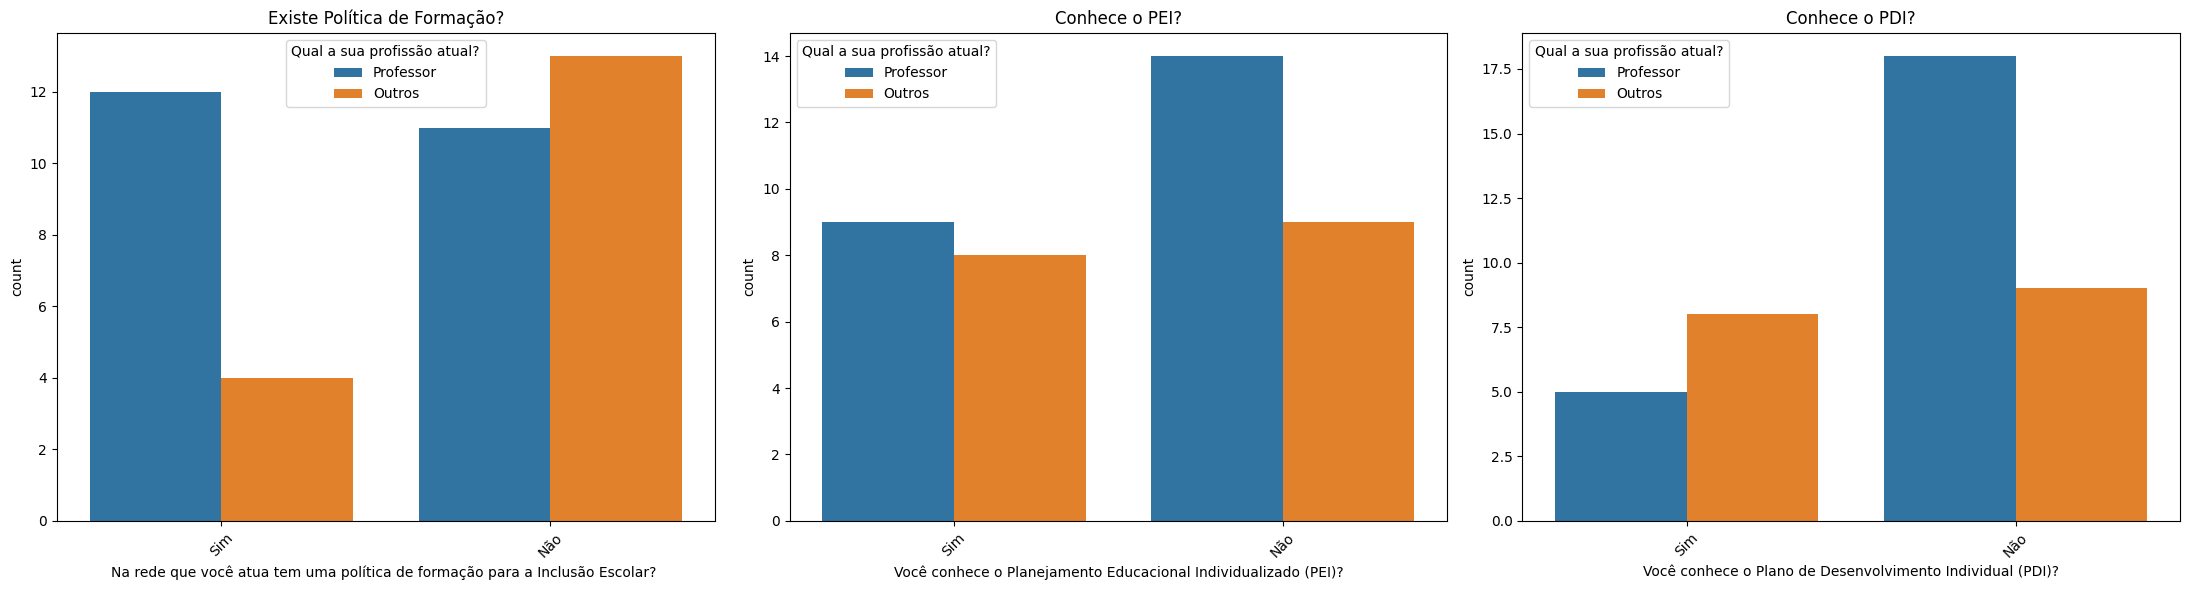

In [ ]:
col_politica = indicador_azul[0]
col_pei = indicador_azul[1]
col_pdi = indicador_azul[2]

fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# Gráfico 1: Política de Formação
sns.countplot(data=df_sbz, x=col_politica, hue='Qual a sua profissão atual?', ax=axes[0])
axes[0].set_title('Existe Política de Formação?')
axes[0].tick_params(axis='x', rotation=45)

# Gráfico 2: Conhece o PEI?
sns.countplot(data=df_sbz, x=col_pei, hue='Qual a sua profissão atual?', ax=axes[1])
axes[1].set_title('Conhece o PEI?')
axes[1].tick_params(axis='x', rotation=45)

# Gráfico 3: Conhece o PDI?
sns.countplot(data=df_sbz, x=col_pdi, hue='Qual a sua profissão atual?', ax=axes[2])
axes[2].set_title('Conhece o PDI?')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

**Conclusões São Braz do Piauí:** em São Braz do Piauí, o Indicador Azul revela uma lacuna documental crítica. Ao contrário de Piranguinho, onde o PDI já era uma ferramenta conhecida, em São Braz a maioria absoluta dos professores desconhece tanto o PDI quanto o PEI. Isso explica por que a palavra 'FORMAÇÃO' foi o grito principal na nuvem de palavras anterior: os profissionais sentem que não possuem sequer as ferramentas básicas de planejamento para trabalhar com a inclusão.

## **Indicador Laranja**

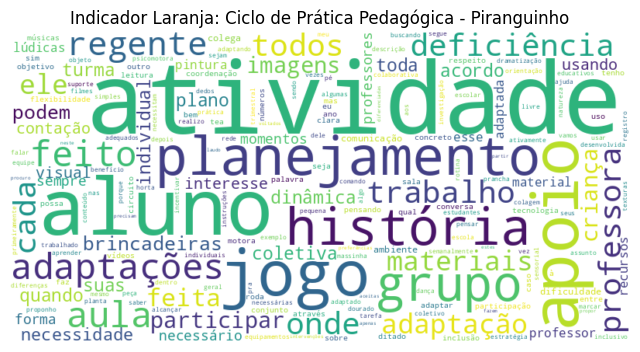

In [ ]:
# --- GERANDO O INDICADOR LARANJA COMPLETO (PLANEJAMENTO + ATIVIDADE + ESTRATÉGIA) ---

def gerar_nuvem_praticas_completa_pirangui(df, nome_cidade):
    # Índice 0: Planejamento / Índice 1: Atividades / Índice 3: Estratégias
    col_plan = indicador_laranja[0]
    col_atv = indicador_laranja[1]
    col_est = indicador_laranja[3]

    # Juntando o texto das três colunas para os Professores
    texto_laranja = " ".join(df[df['Qual a sua profissão atual?'] == 'Professor'][col_plan].dropna().astype(str)) + \
                    " ".join(df[df['Qual a sua profissão atual?'] == 'Professor'][col_atv].dropna().astype(str)) + \
                    " ".join(df[df['Qual a sua profissão atual?'] == 'Professor'][col_est].dropna().astype(str))

    if len(texto_laranja.strip()) > 15:
        # Usando cores que remetem à prática e ação
        nuvem = WordCloud(width=800, height=400, background_color='white',
                           stopwords=stopwords_pt).generate(texto_laranja.lower())

        plt.figure(figsize=(8, 6))
        plt.imshow(nuvem, interpolation='bilinear')
        plt.axis('off')
        plt.title(f'Indicador Laranja: Ciclo de Prática Pedagógica - {nome_cidade}')
        plt.show()
    else:
        print(f"Dados insuficientes para as práticas em {nome_cidade}")

# Rodar para as cidades
gerar_nuvem_praticas_completa_pirangui(df_pir, 'Piranguinho')


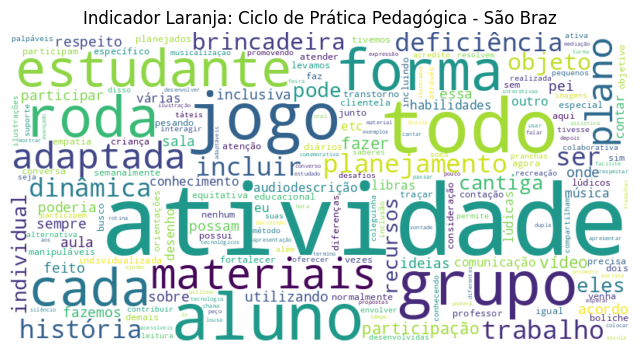

In [ ]:

def gerar_nuvem_praticas_completa_braz(df, nome_cidade):
    # Índice 0: Planejamento / Índice 1: Atividades / Índice 3: Estratégias
    col_plan = indicador_laranja[0]
    col_atv = indicador_laranja[2]
    col_est = indicador_laranja[3]

    # Juntando o texto das três colunas para os Professores
    texto_laranja = " ".join(df[df['Qual a sua profissão atual?'] == 'Professor'][col_plan].dropna().astype(str)) + \
                    " ".join(df[df['Qual a sua profissão atual?'] == 'Professor'][col_atv].dropna().astype(str)) + \
                    " ".join(df[df['Qual a sua profissão atual?'] == 'Professor'][col_est].dropna().astype(str))

    if len(texto_laranja.strip()) > 15:
        # Usando cores que remetem à prática e ação
        nuvem = WordCloud(width=800, height=400, background_color='white',
                           stopwords=stopwords_pt).generate(texto_laranja.lower())

        plt.figure(figsize=(8, 6))
        plt.imshow(nuvem, interpolation='bilinear')
        plt.axis('off')
        plt.title(f'Indicador Laranja: Ciclo de Prática Pedagógica - {nome_cidade}')
        plt.show()
    else:
        print(f"Dados insuficientes para as práticas em {nome_cidade}")

# Rodar para as cidades
gerar_nuvem_praticas_completa_braz(df_sbz, 'São Braz')


**Conclusão:** Ao analisar o Indicador Laranja de forma comparativa entre Piranguinho e São Braz do Piauí, observa-se uma convergência significativa no repertório pedagógico, onde a inclusão é fundamentada primordialmente na ludicidade e na socialização.

# **Amostra Especial de Linguagem e Acessibilidade**
Nesta etapa, a análise deixa de ser geográfica e passa a ser temática. O objetivo é investigar o nível de conhecimento técnico e o repertório de estratégias dos profissionais em relação a três áreas específicas da educação especial: Cegueira, Baixa Visão e Deficiência Neuromotora.

**O que será analisado:**

**1- Conhecimento Técnico:** Identificar se os participantes mencionam recursos específicos (como Braille, Soroban, audiodescrição ou mouses adaptados).

**2- Adaptação Curricular:** Como os professores propõem modificar as atividades de sala de aula para garantir a autonomia e a participação desses estudantes.

**3- Recursos de Tecnologia Assistiva:** Mapear quais ferramentas de tecnologia assistiva são conhecidas ou utilizadas na rede de ensino.

## **1- Conhecimento Técnico:**

In [ ]:
df_pir.columns[13]

'Qual foi o formato do seu curso de graduação?'

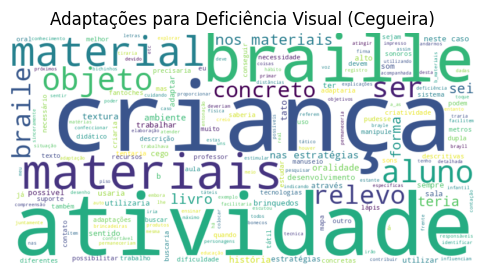

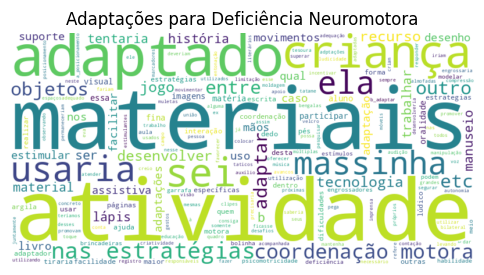

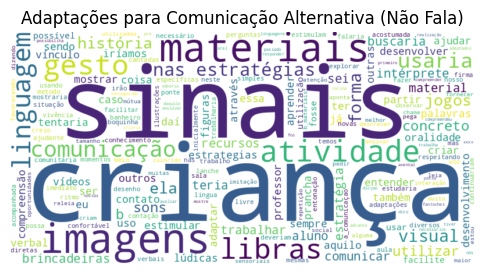

In [ ]:
col_baixa_visao = df_lin.columns[13]
col_nao_fala = df_lin.columns[14]
col_cega = df_lin.columns[15]
col_neuromotora = df_lin.columns[16]
col_intelectual = df_lin.columns[17]
col_auditiva = df_lin.columns[18]

def gerar_nuvem_tecnica(df, coluna, titulo):
    texto = " ".join(df[coluna].dropna().astype(str))
    if len(texto.strip()) > 10:
        nuvem = WordCloud(width=800, height=400, background_color='white',
                           stopwords=stopwords_pt).generate(texto.lower())
        plt.figure(figsize=(6, 5))
        plt.imshow(nuvem, interpolation='bilinear')
        plt.axis('off')
        plt.title(titulo)
        plt.show()

gerar_nuvem_tecnica(df_lin, col_cega, "Adaptações para Deficiência Visual (Cegueira)")
gerar_nuvem_tecnica(df_lin, col_neuromotora, "Adaptações para Deficiência Neuromotora")
gerar_nuvem_tecnica(df_lin, col_nao_fala, "Adaptações para Comunicação Alternativa (Não Fala)")
#gerar_nuvem_tecnica(df_lin, col_intelectual, "Adaptações para deficiência intelectual")
#gerar_nuvem_tecnica(df_lin, col_auditiva, "Adaptações para deficiência auditiva")

**Deficiência Visual (Cegueira)**

-Achados: O termo "Braille" é o pilar central, indicando que há reconhecimento do sistema oficial de escrita. O foco está na transformação do material em "concreto" e no uso de "relevos" e "texturas" para garantir o acesso pelo tato.

-Conclusão: O conhecimento é focado na adaptação física de livros e objetos, mas ainda carece de menções a tecnologias assistivas digitais (como leitores de tela) ou recursos como o Soroban.

**Deficiência Neuromotora**

-Achados: A preocupação principal é a "manipulação". Termos como "massinha", "lápis" e "objetos" mostram que o foco está em como o aluno interage fisicamente com as atividades. Surgem menções a "engrossadores" e "coordenação motora".

-Conclusão: A rede entende a necessidade de adaptar a empunhadura e o acesso ao material, focando muito em atividades de vida diária e artes, mas pouco em mobiliário adaptado ou suportes de tecnologia mais complexos.

**Comunicação Alternativa (Não Fala)**

-Achados: Há uma forte associação com "Libras" e "Sinais", além do uso massivo de "Imagens" e "Gestos" como ponte de comunicação. O termo "Prancha" indica o conhecimento de ferramentas de baixa tecnologia para escolha e expressão.

-Conclusão: Os professores priorizam o canal visual e gestual. Existe uma base para o uso de comunicação alternativa, mas os dados sugerem uma necessidade de diferenciar melhor quando usar Libras (para surdez) vs. sistemas de comunicação por troca de figuras (para crianças não-oralizadas).

## **2- Adaptação Curricular:**

In [ ]:
!jupyter nbconvert --to html "/content/drive/MyDrive/Colab Notebooks/jaima.ipynb" --no-input

[NbConvertApp] Converting notebook /content/drive/MyDrive/Colab Notebooks/jaima.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 9 image(s).
[NbConvertApp] Writing 2044853 bytes to /content/drive/MyDrive/Colab Notebooks/jaima.html
